In [41]:
# Import

import xarray as xr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

In [42]:
# Dataset

ds = xr.open_dataset("data/raw/noaaSSTcoralData.nc")

sst = ds["analysed_sst"].squeeze()

df = sst.to_dataframe().reset_index()
df = df.rename(columns={"analysed_sst": "SST"})

df.head()


,time,latitude,longitude,SST
0,2024-01-01 12:00:00,-17.975,147.024994,29.57
1,2024-01-02 12:00:00,-17.975,147.024994,29.88
2,2024-01-03 12:00:00,-17.975,147.024994,30.18
3,2024-01-04 12:00:00,-17.975,147.024994,30.22
4,2024-01-05 12:00:00,-17.975,147.024994,30.27


In [43]:
# Feature Engineering

baseline = df["SST"].mean()

df["anomaly"] = df["SST"] - baseline

df["heat_stress"] = df["anomaly"].apply(lambda x: x if x > 1 else 0)

df["rolling_stress"] = df["heat_stress"].rolling(window=84).sum()

df[["SST", "anomaly", "rolling_stress"]].head()

df["temp_change"] = df["SST"].diff()

df["temp_acceleration"] = df["temp_change"].diff()


In [44]:
# Prediction 

df["future_stress"] = df["rolling_stress"].shift(-14)

df["risk_label"] = (df["future_stress"] > 3).astype(int)

df[["rolling_stress", "future_stress", "risk_label"]].tail()

,rolling_stress,future_stress,risk_label
361,50.811721,NaN,0
362,52.755574,NaN,0
363,54.789426,NaN,0
364,57.163279,NaN,0
365,59.507131,NaN,0


In [45]:
# Lag Features

df["SST_lag1"] = df["SST"].shift(1)
df["SST_lag7"] = df["SST"].shift(7)
df["SST_lag14"] = df["SST"].shift(14)

df = df.dropna()

df.head()

,time,latitude,longitude,SST,anomaly,heat_stress,rolling_stress,temp_change,temp_acceleration,future_stress,risk_label,SST_lag1,SST_lag7,SST_lag14
83,2024-03-24 12:00:00,-17.975,147.024994,28.58,1.303852,1.303852,190.523607,-0.16,-0.28,173.653607,1,28.74,29.16,29.38
84,2024-03-25 12:00:00,-17.975,147.024994,28.65,1.373852,1.373852,189.603607,0.07,0.23,173.023607,1,28.58,28.97,29.25
85,2024-03-26 12:00:00,-17.975,147.024994,28.94,1.663852,1.663852,188.663607,0.29,0.22,172.383607,1,28.65,28.53,29.07
86,2024-03-27 12:00:00,-17.975,147.024994,29.04,1.763852,1.763852,187.523607,0.10,-0.19,171.613607,1,28.94,28.89,29.17
87,2024-03-28 12:00:00,-17.975,147.024994,28.88,1.603852,1.603852,186.183607,-0.16,-0.26,170.773607,1,29.04,28.81,29.23


In [46]:
# 1 Model training

X = df[["SST", "SST_lag1", "SST_lag7", "SST_lag14"]]
y = df["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = XGBClassifier(eval_metric="logloss")
model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, preds))

ROC-AUC: 0.6521739130434783


In [47]:
# Evaluation

X = df[["SST", "SST_lag1", "SST_lag7", "SST_lag14"]]
y = df["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = XGBClassifier(eval_metric="logloss")
model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, preds))

ROC-AUC: 0.6521739130434783


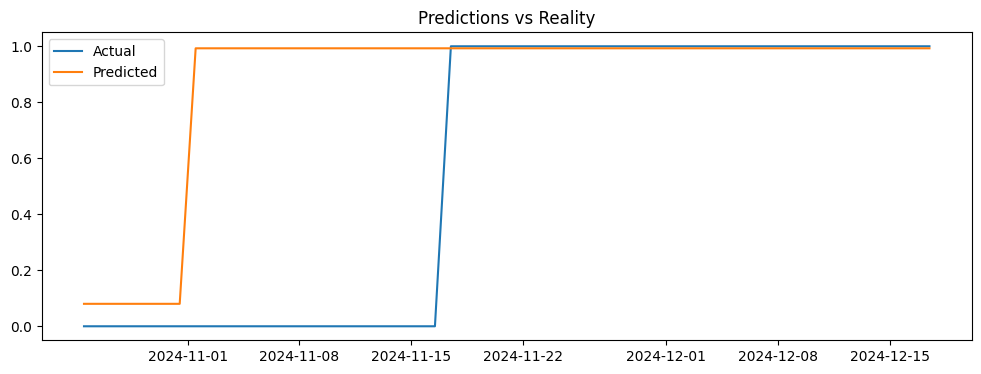

In [48]:
# Visual Check

plt.figure(figsize=(12,4))

plt.plot(df["time"].iloc[-len(preds):], y_test, label="Actual")
plt.plot(df["time"].iloc[-len(preds):], preds, label="Predicted")

plt.legend()
plt.title("Predictions vs Reality")
plt.show()

In [49]:
# Complex

X = df[[
    "SST",
    "SST_lag1",
    "SST_lag7",
    "SST_lag14",
    "rolling_stress"
]]

In [50]:
X = df[[
    "SST",
    "SST_lag1",
    "SST_lag7",
    "SST_lag14",
    "anomaly",
    "rolling_stress"
]]

In [51]:
print("ROC-AUC:", roc_auc_score(y_test, preds))

ROC-AUC: 0.6521739130434783


In [52]:
df["rolling_mean_7"] = df["SST"].rolling(7).mean()
df["rolling_mean_14"] = df["SST"].rolling(14).mean()

In [53]:
X = df[[
    "SST",
    "SST_lag1",
    "SST_lag7",
    "SST_lag14",
    "anomaly",
    "rolling_stress",
    "rolling_mean_7",
    "rolling_mean_14"
]]

In [54]:
print("ROC-AUC:", roc_auc_score(y_test, preds))

ROC-AUC: 0.6521739130434783


In [55]:
# ===== FINAL PIPELINE (RUN THIS ONLY) =====

import xarray as xr
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

# Load
ds = xr.open_dataset("data/raw/noaaSSTcoralData.nc")
sst = ds["analysed_sst"].squeeze()

df = sst.to_dataframe().reset_index()
df = df.rename(columns={"analysed_sst": "SST"})

# Features
baseline = df["SST"].mean()
df["anomaly"] = df["SST"] - baseline
df["heat_stress"] = df["anomaly"].apply(lambda x: x if x > 1 else 0)
df["rolling_stress"] = df["heat_stress"].rolling(window=84).sum()

df["temp_change"] = df["SST"].diff()
df["temp_acceleration"] = df["temp_change"].diff()

# Target
df["future_stress"] = df["rolling_stress"].shift(-14)
df["risk_label"] = (df["future_stress"] > 3).astype(int)

# Lags
df["SST_lag1"] = df["SST"].shift(1)
df["SST_lag7"] = df["SST"].shift(7)
df["SST_lag14"] = df["SST"].shift(14)

df = df.dropna()

# Model
X = df[[
    "SST",
    "SST_lag1",
    "SST_lag7",
    "SST_lag14",
    "anomaly",
    "rolling_stress",
    "temp_change",
    "temp_acceleration"
]]

y = df["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = XGBClassifier(eval_metric="logloss")
model.fit(X_train, y_train)

pred_labels = (preds > 0.3).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, preds))

pred_labels = model.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_labels))

ROC-AUC: 0.6521739130434783
Confusion Matrix:
[[23  0]
 [27  4]]


In [56]:
model = XGBClassifier(
    eval_metric="logloss",
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
)

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:, 1]

pred_labels = (preds > 0.3).astype(int)

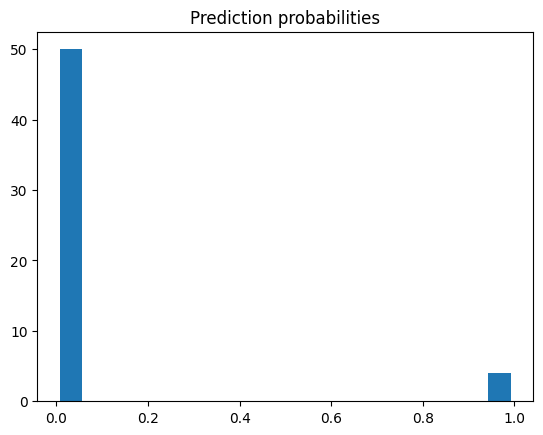

In [57]:
plt.hist(preds, bins=20)
plt.title("Prediction probabilities")
plt.show()

In [58]:
print(confusion_matrix(y_test, pred_labels))

[[23  0]
 [27  4]]


In [59]:
print("ROC-AUC:", roc_auc_score(y_test, preds))


ROC-AUC: 0.564516129032258
